# CSE36301 Assignment4


# 1. CNN

In [1]:
# Default Libraries
import os
import math
import random
from pathlib import Path
import shutil

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# If you're training a CNN model, choosing a GPU is recommended.
# Check the 'cuda' output in the code below.
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device", device)

Using device cuda


## Download Tiny ImageNet

In [2]:
%%bash
# It takes about 2 to 3 minutes.
if [ ! -d "tiny-imagenet-200" ]; then
  wget -q http://cs231n.stanford.edu/tiny-imagenet-200.zip
  unzip -q tiny-imagenet-200.zip
else
  echo "tiny-imagenet-200 already exists  skip download"
fi

tiny-imagenet-200 already exists  skip download


In [3]:
###
# you can find the label information in the following file:
# tiny-imagenet-200/words.txt
###

###
# tiny-imagenet contains a total of 120,000 images:
#   - 100,000 for training
#   -  10,000 for validation
#   -  10,000 for testing
#
# each image has a resolution of 64 x 64 x 3 (W x H x C).
###

# Reorganization
val_dir = Path("tiny-imagenet-200/val")
images_dir = val_dir / "images"
annot_file = val_dir / "val_annotations.txt"
target_root = val_dir / "images_by_class"

if not target_root.exists():
    target_root.mkdir(parents=True, exist_ok=True)
    with open(annot_file, "r") as f:
        for line in f:
            parts = line.split("\t")
            img_name, wnid = parts[0], parts[1]
            wnid_dir = target_root / wnid
            wnid_dir.mkdir(parents=True, exist_ok=True)
            src = images_dir / img_name
            dst = wnid_dir / img_name
            if src.exists():
                shutil.move(str(src), str(dst))
    print("Reorganized validation images into", target_root)
else:
    print("Validation images already reorganized at", target_root)

Validation images already reorganized at tiny-imagenet-200/val/images_by_class


In [4]:
# 3x3 Blur kernel
BLUR = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=np.float32)

# Sharpen filter
SHARPEN = np.array([
    [0, -1,  0],
    [-1, 5, -1],
    [0, -1,  0]
], dtype=np.float32)

# Edge detection (Sobel X)
SOBEL_X = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# Edge detection (Sobel Y)
SOBEL_Y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

# Laplacian filter
LAPLACIAN = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
], dtype=np.float32)


## TODO: 2D Convolution Implementation

image shape: (64, 64, 3)


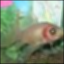

In [5]:
import numpy as np

def conv2d(x, kernel, stride=1, padding=0):
    """
    Implement 2D convolution using only numpy operations.

    x: input image (H, W)
    kernel: convolution filter (kH, kW)
    stride: stride size
    padding: zero padding size
    """

    # 1. TODO: pad the input (use np.pad)
    x_padded = np.pad(x, padding, mode='constant', constant_values=0)

    # 2. TODO: compute output height and width
    H_out = (x_padded.shape[0] - kernel.shape[0]) // stride + 1
    W_out = (x_padded.shape[1] - kernel.shape[1]) // stride + 1

    # 3. TODO: initialize output feature map
    output = np.zeros((H_out, W_out), dtype=np.float32)

    # 4. TODO: nested loops to slide kernel over the image
    #    multiply element-wise with kernel
    #    take the sum
    for i in range(H_out):
        for j in range(W_out):
            h = i * stride
            w = j * stride
            patch = x_padded[h:h + kernel.shape[0], w:w + kernel.shape[1]]
            output[i, j] = np.sum(patch * kernel)

    return output

def apply_filter_rgb(img, kernel):
    R, G, B = img_np[:, :, 0], img_np[:, :, 1], img_np[:, :, 2]
    R = conv2d(R, kernel, padding=1)
    G = conv2d(G, kernel, padding=1)
    B = conv2d(B, kernel, padding=1)

    out = np.stack([R, G, B], axis=2) # axis for channel
    out = np.clip(out, 0, 255)        # range limit for image pixel
    return out

# example image
img_path = "tiny-imagenet-200/train/n01443537/images/n01443537_0.JPEG"

# load and convert to numpy
img = Image.open(img_path).resize((64, 64))
img_np = np.array(img).astype(np.float32)
print("image shape:", img_np.shape)

###
# kernel examples: BLUR, SHARPEN, SOBEL_X, SOBEL_Y, LAPLACIAN
###
x = img_np
kernel = BLUR
filtered_image = apply_filter_rgb(x, kernel).astype(np.uint8)
img_pil = Image.fromarray(filtered_image)
img_pil

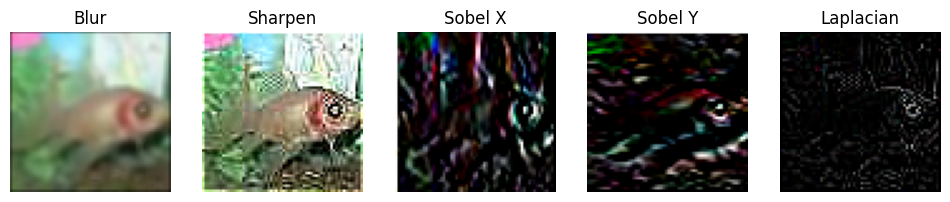

In [6]:
# All kernels Visualization
import numpy as np
import matplotlib.pyplot as plt

# Define kernels
kernels = {
    "Blur": BLUR,
    "Sharpen": SHARPEN,
    "Sobel X": SOBEL_X,
    "Sobel Y": SOBEL_Y,
    "Laplacian": LAPLACIAN
}

# Visualization
x = img_np
plt.figure(figsize=(12, 8))
for i, (name, kernel) in enumerate(kernels.items(), 1):
    filtered_image = apply_filter_rgb(x, kernel).astype(np.uint8)
    plt.subplot(1, 5, i)
    plt.imshow(filtered_image)
    plt.title(name)
    plt.axis('off')
plt.show()

## Define Tiny ImageNet DataLoader


In [7]:
def get_tiny_imagenet_dataloaders(
    batch_size=64,
    img_size=64
):
    transform_train = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ])
    transform_test = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])

    train_root = "tiny-imagenet-200/train"
    val_root = "tiny-imagenet-200/val/images_by_class"

    train_set = datasets.ImageFolder(train_root, transform=transform_train)
    val_set = datasets.ImageFolder(val_root, transform=transform_test)

    print("Number of train images", len(train_set))
    print("Number of val images", len(val_set))
    print("Number of classes", len(train_set.classes))

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    return train_loader, val_loader

## Define CNN model


In [8]:
class CNN(nn.Module):
    def __init__(
        self,
        num_classes=200,
        num_layers=3,
        base_filters=32,
        use_batchnorm=True
    ):
        super().__init__()

        # num_layers should be greater than 0
        assert num_layers >= 1

        # For RGB channels
        in_channels = 3

        # Define layers
        layers = []
        for i in range(num_layers):
            # 32, 64, 128, ...
            out_channels = base_filters * (2 ** i)
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2))

            # channels num should be next_in_channels == prev_out_channels
            in_channels = out_channels

        # Sequential (CNN)
        self.feature_extractor = nn.Sequential(*layers)

        # Classifier (MLP)
        spatial_size = 64 // (2 ** num_layers)
        self.classifier = nn.Linear(in_channels * spatial_size * spatial_size, num_classes)

    def forward(self, x):
        feats = self.feature_extractor(x)
        feats_flat = feats.view(feats.size(0), -1)
        logits = self.classifier(feats_flat)
        return logits

## TODO: CNN training loop and eval function with visualizing feature map function


In [ ]:
def visualize_feature_maps(model, image, layer_idx=0):
    model.eval()
    if image.ndim == 3:
        # for input
        image = image.unsqueeze(0)

    layers = list(model.feature_extractor.children())
    x = image.to(device)
    for i in range(layer_idx + 1):
        x = layers[i](x)

    feature_maps = x.detach().cpu()
    num_maps = min(8, feature_maps.size(1))

    plt.figure(figsize=(12, 6))
    for i in range(num_maps):
        plt.subplot(2, 4, i + 1)
        fm = feature_maps[0, i]
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-5)
        plt.imshow(fm, cmap="gray")
        plt.axis("off")

    plt.suptitle(f"Feature maps at layer index {layer_idx}")
    plt.show()

def train_one_epoch_cnn(model, loader, optimizer, criterion, epoch, device=device):
    model.train()
    running_loss = 0.0
    total = 0
    correct = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Train Epoch {epoch}  Loss {epoch_loss:.4f}  Acc {epoch_acc*100:.2f} percent")
    return epoch_loss, epoch_acc

def eval_cnn(x, model, loader, criterion, device=device):
    model.eval()

    ###
    # TODO: Take any input image (x, --you can change input x accordingly--), and
    # Modify the code so that feature maps from every layer ("all filters", not 8 filters) are stored in history.
    # Hint: Use the visualize_feature_maps function above.
    ###
    feature_maps = []
    with torch.no_grad():
        input_image = x  # 시각화용으로 원본 이미지 따로 보관
        activation = x.to(device)
        for layer_idx, layer in enumerate(model.feature_extractor):
            activation = layer(activation)

            if isinstance(layer, nn.Conv2d):
                feature_maps.append(activation.detach().cpu())
                # visualize_feature_maps(model, input_image, layer_idx=layer_idx)
                # 너무 시각화 많이 나와서 이후에 따로 해줌

    running_loss = 0.0
    total = 0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Val   Loss {epoch_loss:.4f}  Acc {epoch_acc*100:.2f} percent")

    # TODO: return feature maps
    return epoch_loss, epoch_acc, feature_maps

def train_cnn(x, model, train_loader, val_loader, lr=1e-3, epochs=2, device=device):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(device)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_fm": []}
    for epoch in range(1, epochs + 1):
        tl, ta = train_one_epoch_cnn(model, train_loader, optimizer, criterion, epoch, device)
        vl, va, vf = eval_cnn(x, model, val_loader, criterion, device)
        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        history["val_fm"].append(vf)

    return history

## TODO: CNN Training and Analysis

Caution
- Training takes about 1 minute per epoch.
- You may adjust the hyperparameters to improve accuracy.
    - If you change the hyperparameters, how do the feature maps change? (Extra credit, Not necessary)

In [10]:
BATCH_SIZE = 64
IMAGE_SIZE = 64
train_loader, val_loader = get_tiny_imagenet_dataloaders(
    batch_size=BATCH_SIZE,
    img_size=IMAGE_SIZE
)

CLASS = 200
LAYER = 5  # orig = 3
FILTER = 32
BATCHNORM = True
model = CNN(
    num_classes   = CLASS,
    num_layers    = LAYER,
    base_filters  = FILTER,
    use_batchnorm = BATCHNORM
)

x = img
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])
transform_x = transform(x).unsqueeze(0) # for fitting batch shape

LR = 5e-4  # orig = 1e-3
EPOCHS = 8 # orig = 100
history = train_cnn(transform_x, model, train_loader, val_loader, lr=LR, epochs=EPOCHS)

Number of train images 100000
Number of val images 10000
Number of classes 200
Train Epoch 1  Loss 4.0208  Acc 14.93 percent
Val   Loss 4.0044  Acc 16.10 percent
Train Epoch 2  Loss 3.1396  Acc 28.43 percent
Val   Loss 3.1438  Acc 28.60 percent
Train Epoch 3  Loss 2.7297  Acc 36.18 percent
Val   Loss 2.8616  Acc 33.34 percent
Train Epoch 4  Loss 2.4331  Acc 41.85 percent
Val   Loss 2.7376  Acc 36.75 percent
Train Epoch 5  Loss 2.1877  Acc 47.06 percent
Val   Loss 2.5500  Acc 40.51 percent
Train Epoch 6  Loss 1.9686  Acc 51.45 percent
Val   Loss 2.5083  Acc 42.12 percent
Train Epoch 7  Loss 1.7653  Acc 56.03 percent
Val   Loss 2.5772  Acc 40.27 percent
Train Epoch 8  Loss 1.5682  Acc 60.30 percent
Val   Loss 2.5869  Acc 41.62 percent


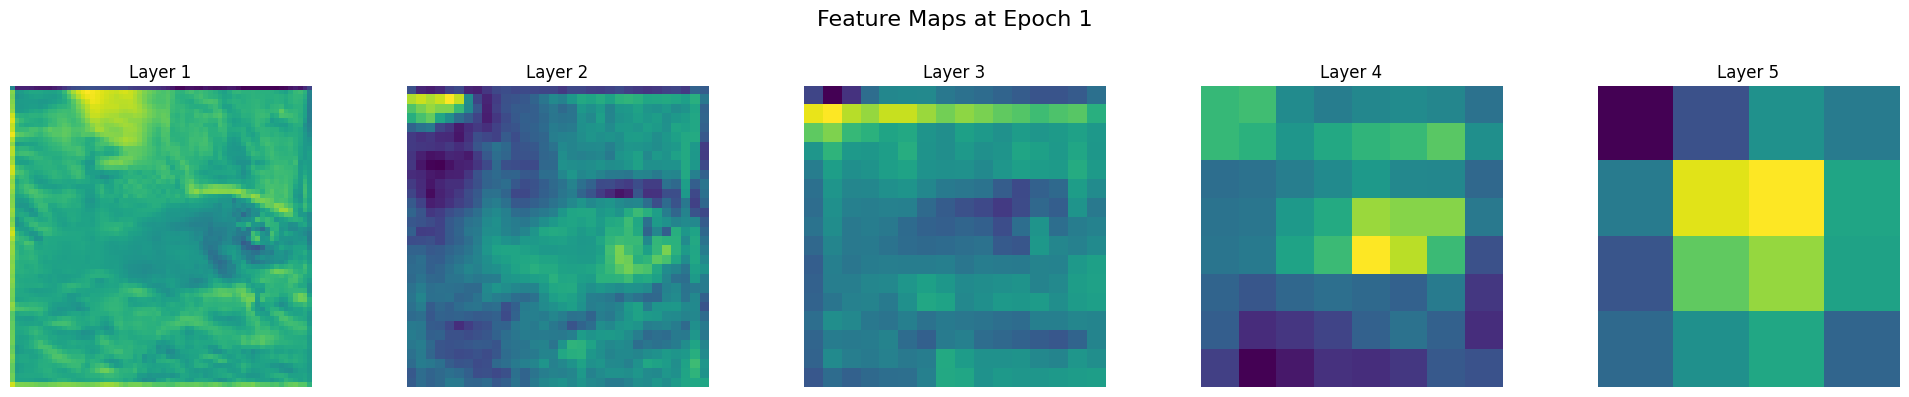

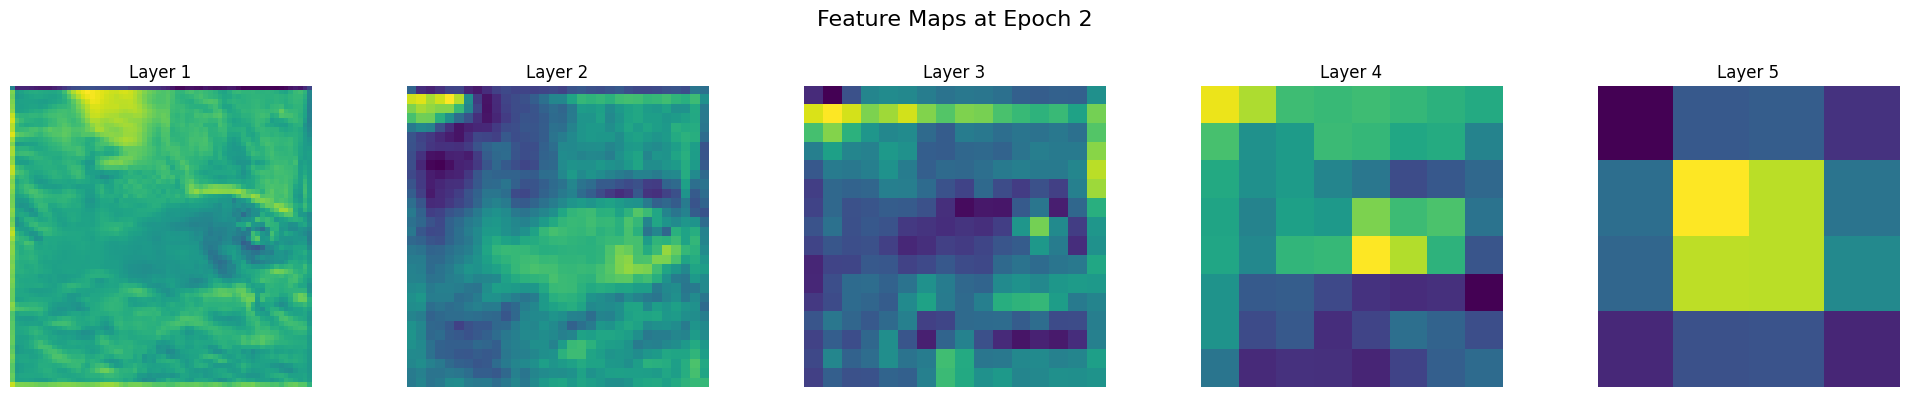

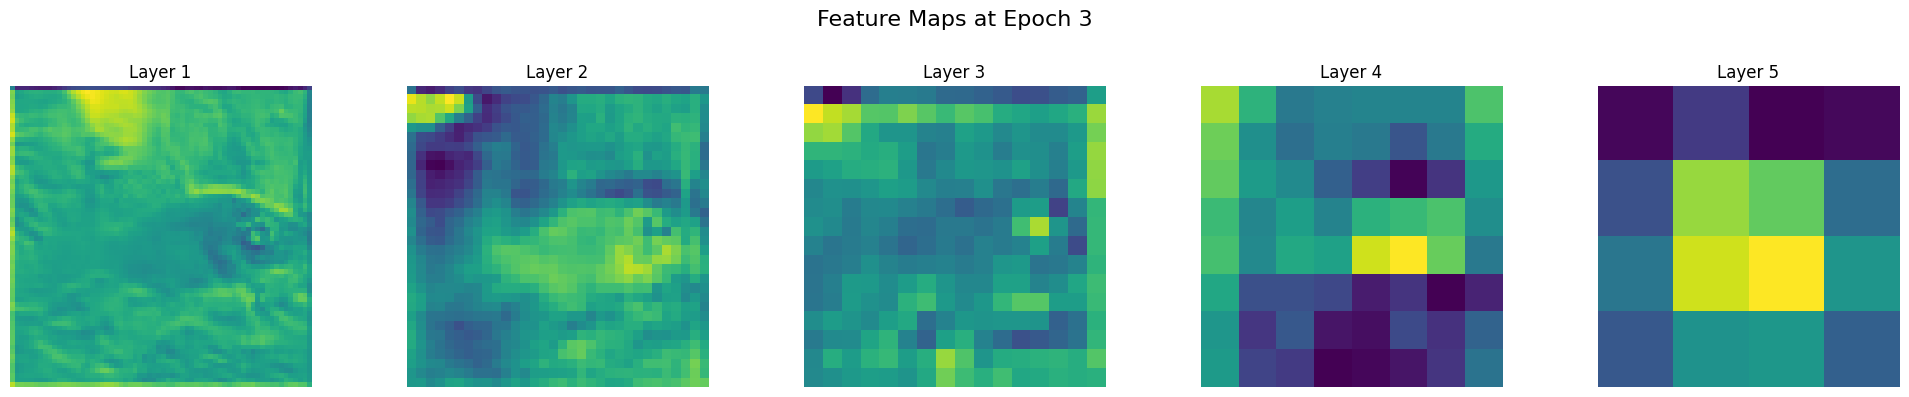

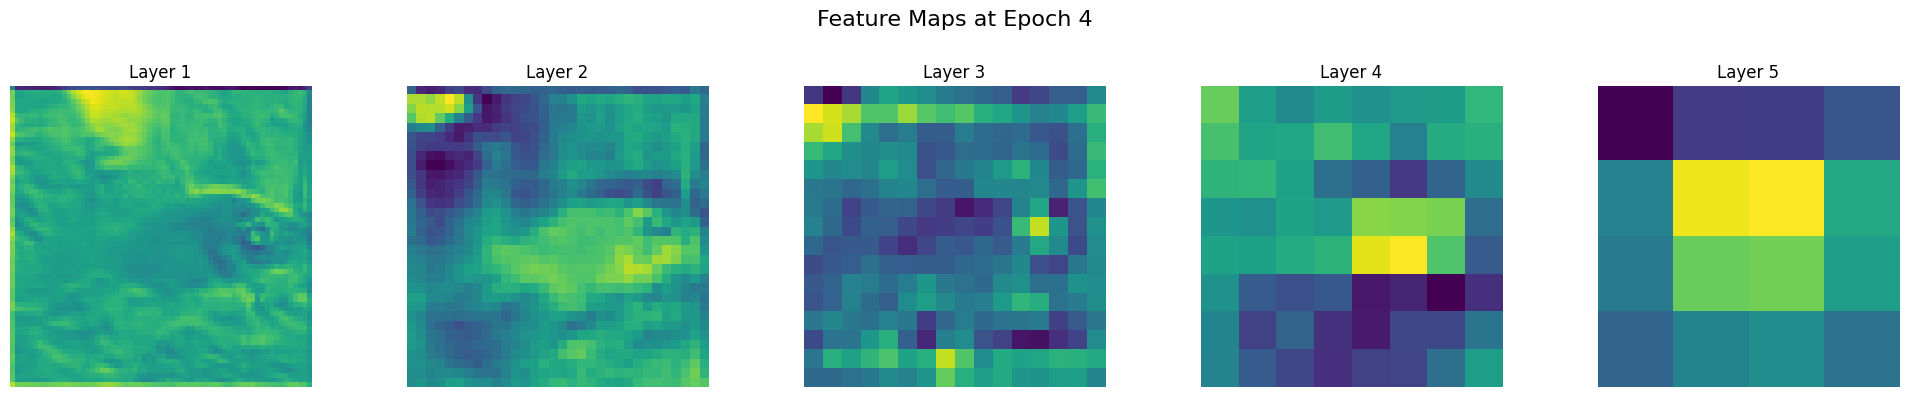

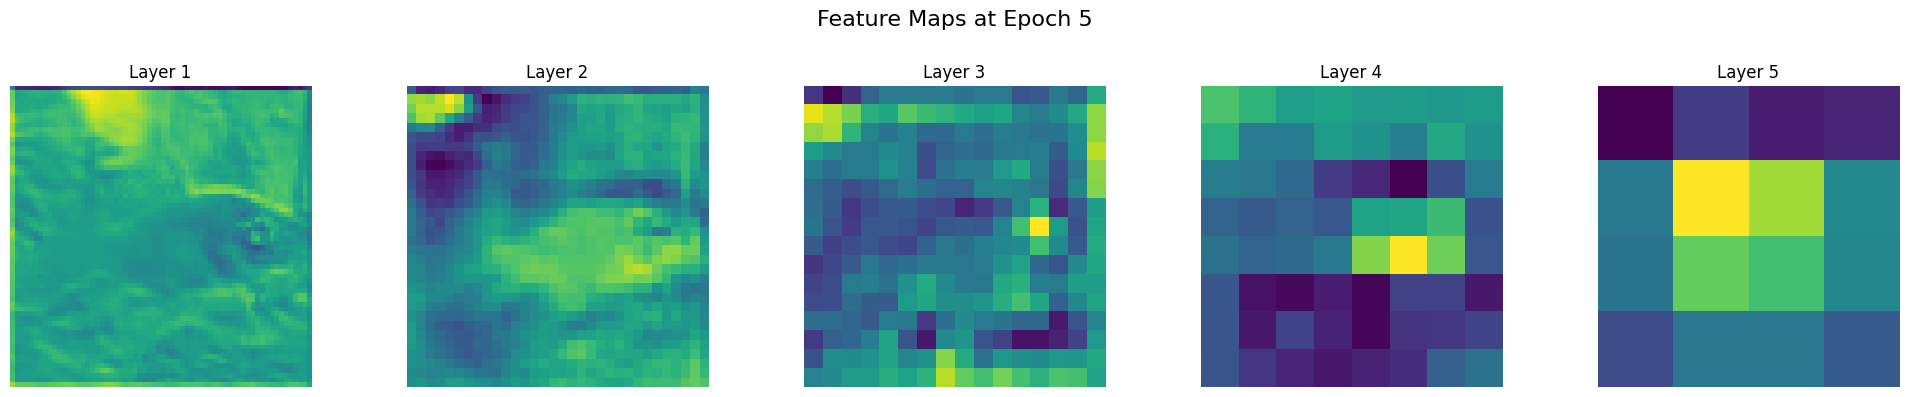

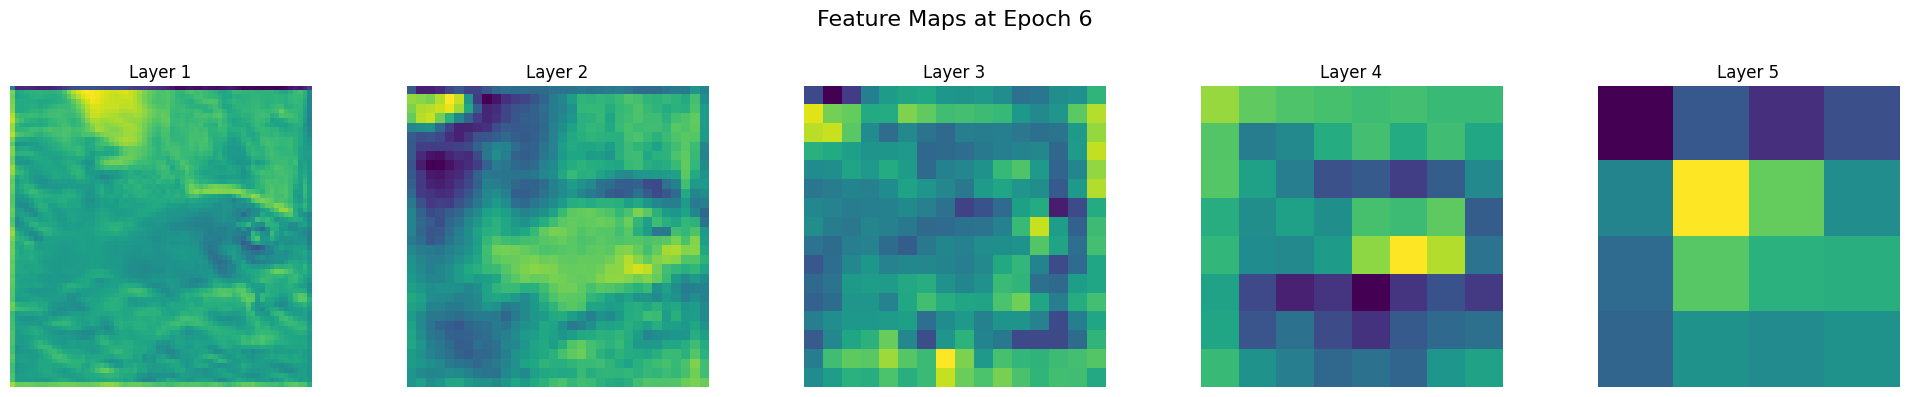

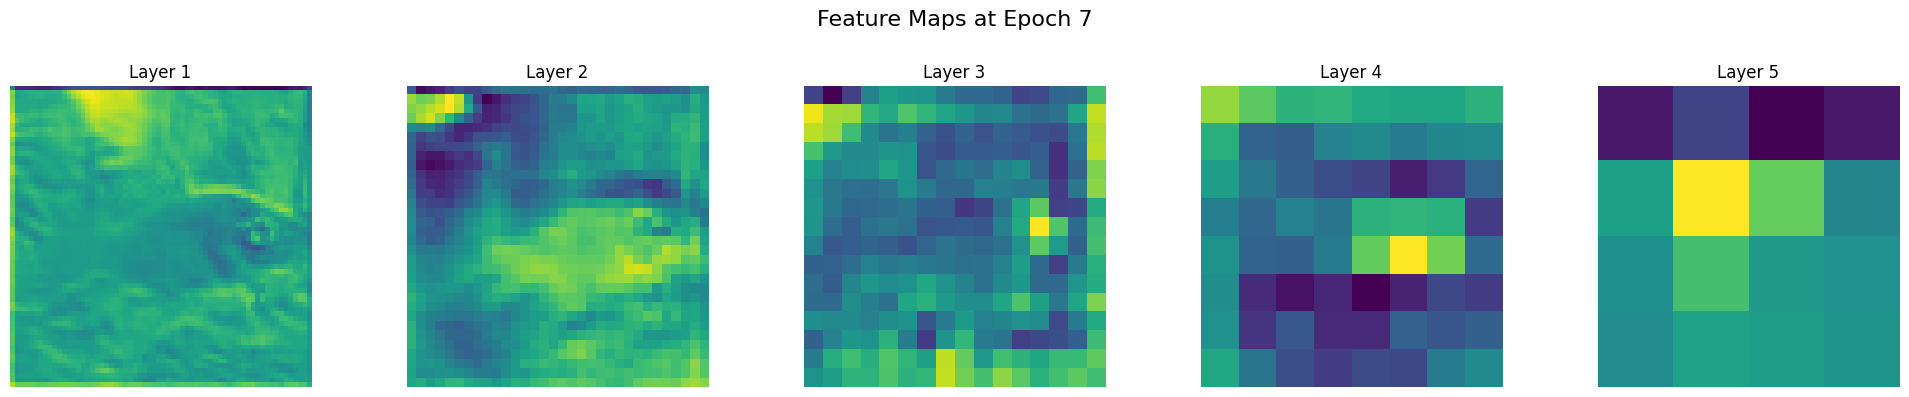

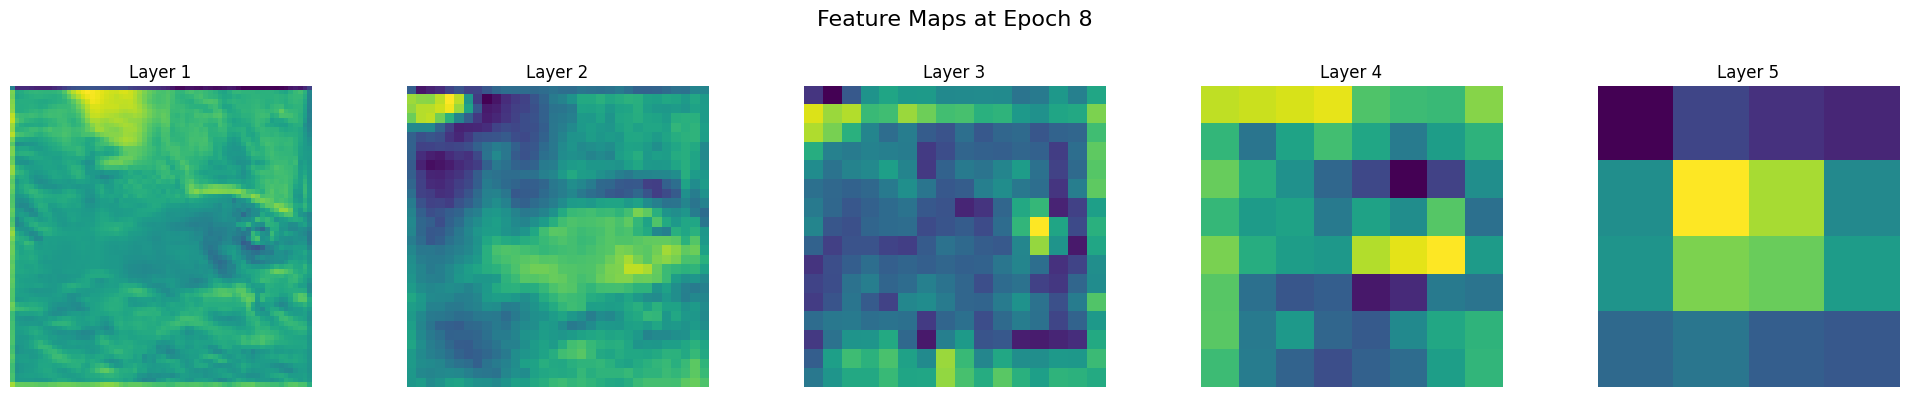

Feature Map Statistics (per epoch)
Epoch  Layer    Mean      Std    Sparsity(%)
1       1        -0.0049    0.2610      3.00
1       2        -0.2690    0.7450      1.38
1       3        -0.1764    1.4654      0.53
1       4        -0.1643    1.7539      0.45
1       5        -0.6418    1.9031      0.33
2       1        -0.0071    0.2631      3.92
2       2        -0.3431    0.9015      1.18
2       3        -0.5579    1.8688      0.47
2       4        -0.7677    2.2081      0.32
2       5        -0.6463    2.3609      0.43
3       1        -0.0031    0.2656      2.68
3       2        -0.4706    1.0559      0.98
3       3        -0.7981    1.9080      0.42
3       4        -0.9549    2.4621      0.31
3       5        -0.7834    2.6079      0.24
4       1         0.0031    0.2814      2.38
4       2        -0.5560    1.1491      0.80
4       3        -0.9307    2.0797      0.38
4       4        -1.3466    2.7595      0.21
4       5        -0.8809    2.6236      0.37
5       1         0.

In [11]:
# TODO: Analyses feature maps per epoch from history
# Hint: You can freely analyze how the "feature" change.

num_epochs = len(history["val_fm"])
num_layers = len(history["val_fm"][0])

for epoch_idx in range(num_epochs):
    feature_maps = history["val_fm"][epoch_idx]

    fig, axes = plt.subplots(1, num_layers, figsize=(4 * num_layers, 4))
    fig.suptitle(f"Feature Maps at Epoch {epoch_idx + 1}", fontsize=16)

    for layer_idx in range(num_layers):
        ax = axes[layer_idx] if num_layers > 1 else axes
        
        # [batch, channel, H, W]
        fm = feature_maps[layer_idx][0, 0].numpy()

        fm_norm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)

        ax.imshow(fm_norm, cmap="viridis")
        ax.axis("off")
        ax.set_title(f"Layer {layer_idx + 1}")

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

print("Feature Map Statistics (per epoch)")
print("Epoch  Layer    Mean      Std    Sparsity(%)")

for epoch_idx in range(num_epochs):
    feature_maps = history["val_fm"][epoch_idx]

    for layer_idx in range(num_layers):
        fm = feature_maps[layer_idx]   # [B, C, H, W]

        mean_activation = fm.mean().item()
        std_activation = fm.std().item()
        sparsity = (fm.abs() < 0.01).float().mean().item() * 100

        print(f"{epoch_idx + 1}       {layer_idx + 1}       {mean_activation:8.4f}  {std_activation:8.4f}  {sparsity:8.2f}")

In [12]:
# Save CNN model for later use (clustering)
cnn_model = model

### num_layers = 3 ablation
Q1. (Extra credit) If you change the hyperparameters, how do the feature maps change?

Number of train images 100000
Number of val images 10000
Number of classes 200
Train Epoch 1  Loss 4.2823  Acc 13.90 percent
Val   Loss 3.6747  Acc 20.84 percent
Train Epoch 2  Loss 3.3763  Acc 25.70 percent
Val   Loss 3.3923  Acc 25.75 percent
Train Epoch 3  Loss 3.0031  Acc 32.36 percent
Val   Loss 3.2172  Acc 28.97 percent
Train Epoch 4  Loss 2.7152  Acc 37.88 percent
Val   Loss 3.0880  Acc 31.53 percent
Train Epoch 5  Loss 2.4601  Acc 42.94 percent
Val   Loss 3.0289  Acc 32.58 percent
Train Epoch 6  Loss 2.2285  Acc 47.73 percent
Val   Loss 3.0222  Acc 33.31 percent
Train Epoch 7  Loss 2.0234  Acc 52.00 percent
Val   Loss 3.1252  Acc 32.40 percent
Train Epoch 8  Loss 1.8380  Acc 55.83 percent
Val   Loss 3.1348  Acc 32.40 percent


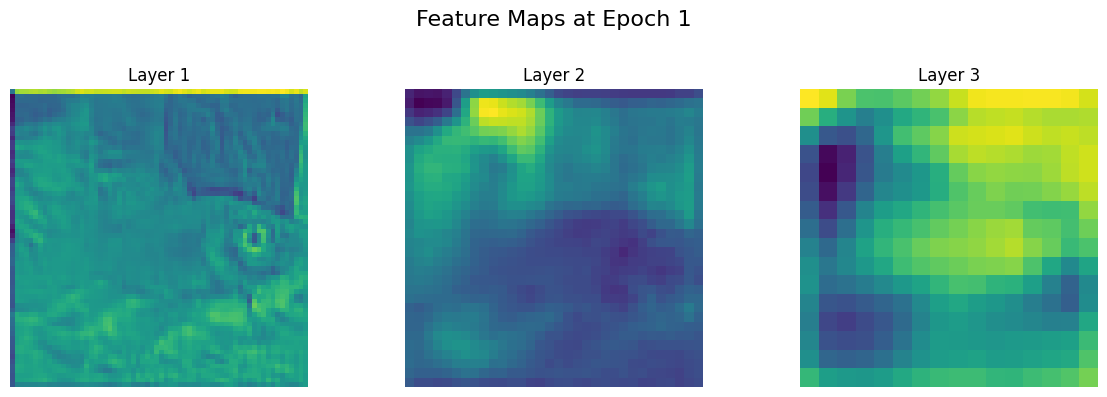

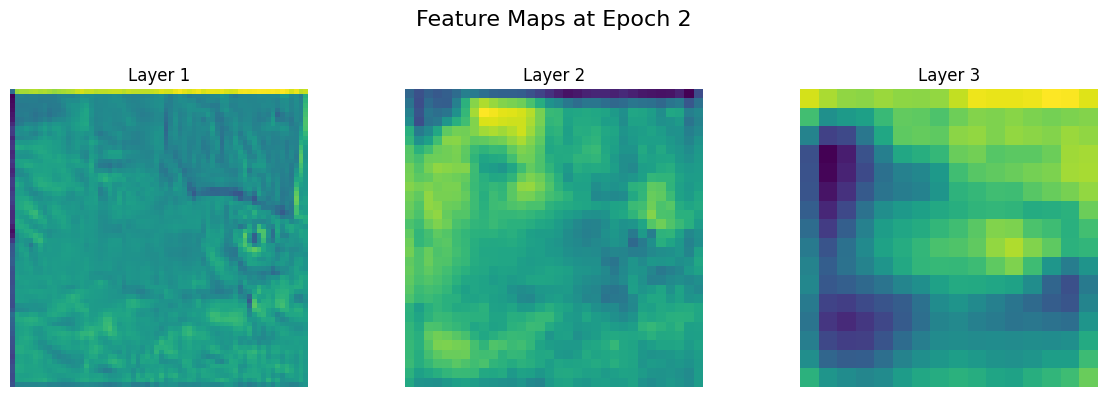

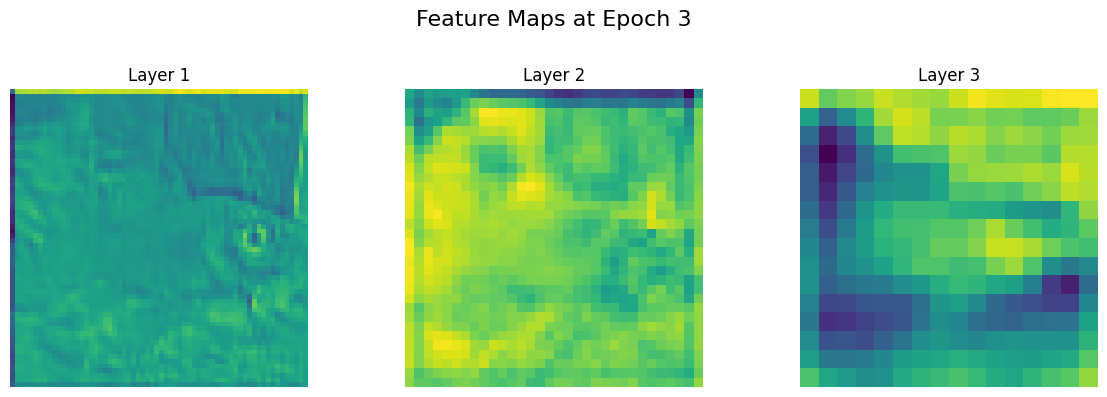

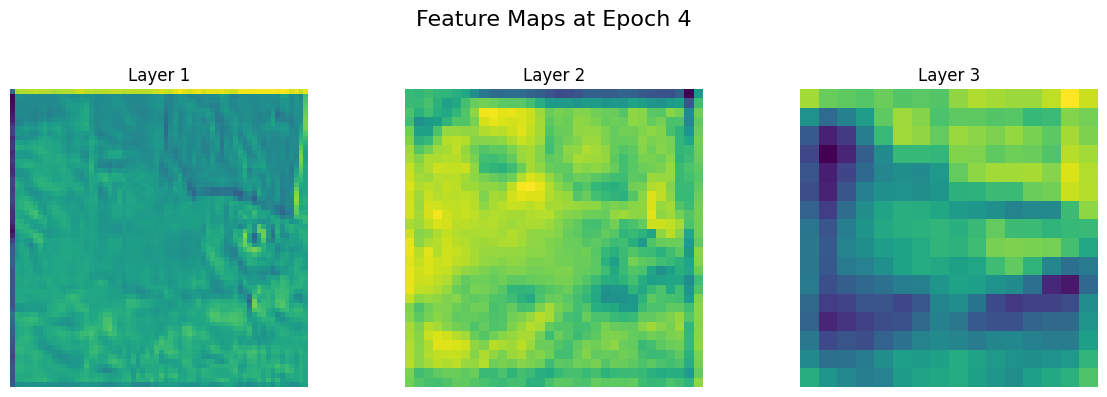

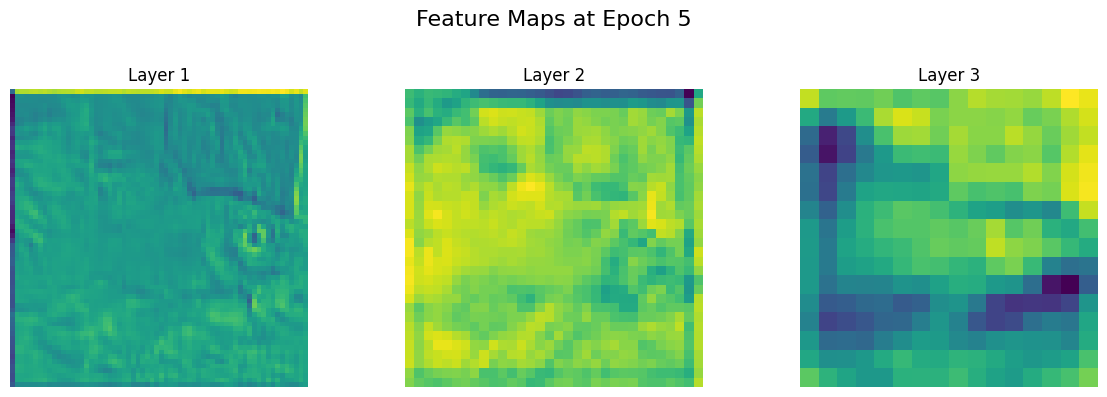

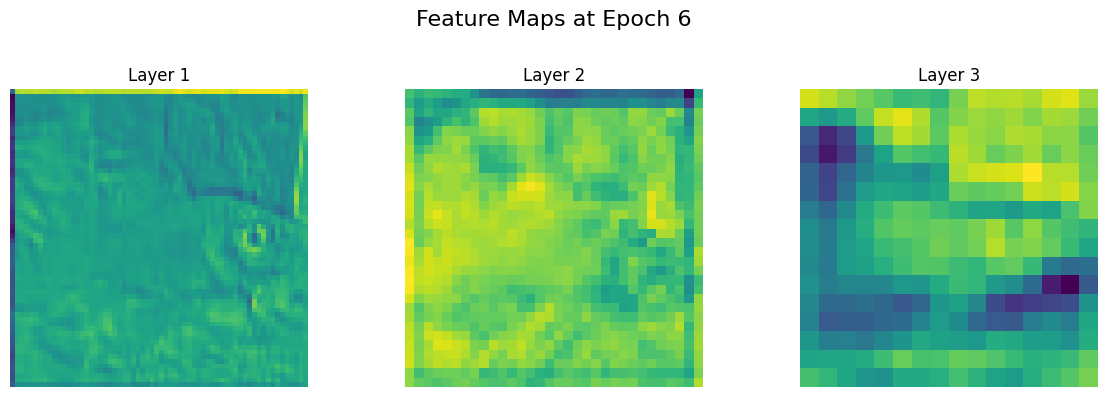

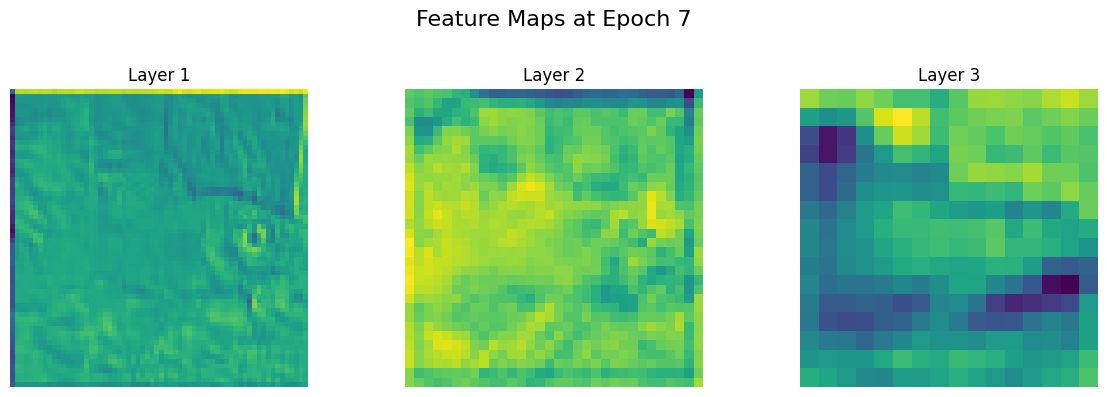

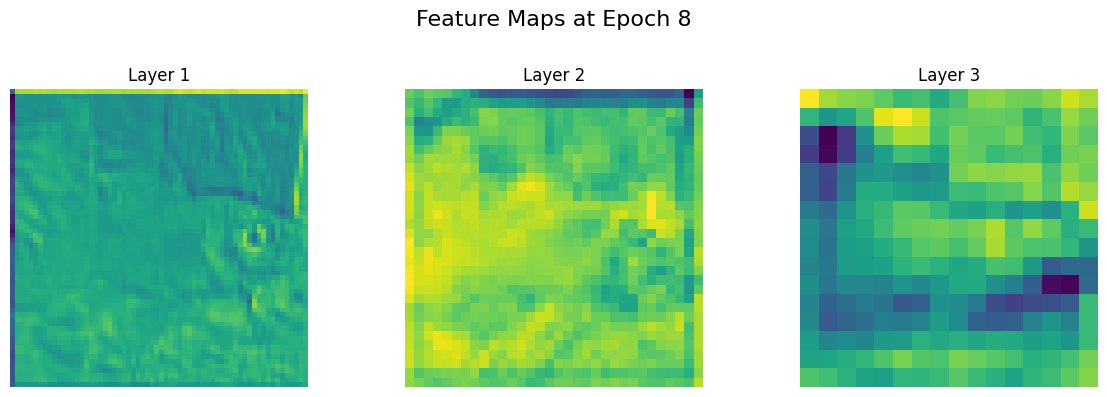

In [13]:
BATCH_SIZE = 64
IMAGE_SIZE = 64
train_loader, val_loader = get_tiny_imagenet_dataloaders(
    batch_size=BATCH_SIZE,
    img_size=IMAGE_SIZE
)

CLASS = 200
LAYER = 3  # ours = 5
FILTER = 32
BATCHNORM = True
model = CNN(
    num_classes   = CLASS,
    num_layers    = LAYER,
    base_filters  = FILTER,
    use_batchnorm = BATCHNORM
)

x = img
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])
transform_x = transform(x).unsqueeze(0) # for fitting batch shape

LR = 5e-4
EPOCHS = 8
history = train_cnn(transform_x, model, train_loader, val_loader, lr=LR, epochs=EPOCHS)

num_epochs = len(history["val_fm"])
num_layers = len(history["val_fm"][0])

for epoch_idx in range(num_epochs):
    feature_maps = history["val_fm"][epoch_idx]

    fig, axes = plt.subplots(1, num_layers, figsize=(4 * num_layers, 4))
    fig.suptitle(f"Feature Maps at Epoch {epoch_idx + 1}", fontsize=16)

    for layer_idx in range(num_layers):
        ax = axes[layer_idx] if num_layers > 1 else axes
        
        # [batch, channel, H, W]
        fm = feature_maps[layer_idx][0, 0].numpy()

        fm_norm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)

        ax.imshow(fm_norm, cmap="viridis")
        ax.axis("off")
        ax.set_title(f"Layer {layer_idx + 1}")

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

### base_filters = 16 ablation
Q1. (Extra credit) If you change the hyperparameters, how do the feature maps change?

Number of train images 100000
Number of val images 10000
Number of classes 200
Train Epoch 1  Loss 4.0370  Acc 14.49 percent
Val   Loss 3.7570  Acc 18.75 percent
Train Epoch 2  Loss 3.2840  Acc 25.76 percent
Val   Loss 3.2469  Acc 26.46 percent
Train Epoch 3  Loss 2.9651  Acc 31.70 percent
Val   Loss 3.0990  Acc 29.12 percent
Train Epoch 4  Loss 2.7377  Acc 36.24 percent
Val   Loss 2.9408  Acc 32.30 percent
Train Epoch 5  Loss 2.5530  Acc 39.71 percent
Val   Loss 2.8517  Acc 34.12 percent
Train Epoch 6  Loss 2.4029  Acc 42.54 percent
Val   Loss 2.8326  Acc 34.38 percent
Train Epoch 7  Loss 2.2697  Acc 45.27 percent
Val   Loss 2.8071  Acc 36.00 percent
Train Epoch 8  Loss 2.1498  Acc 47.85 percent
Val   Loss 2.7163  Acc 37.48 percent


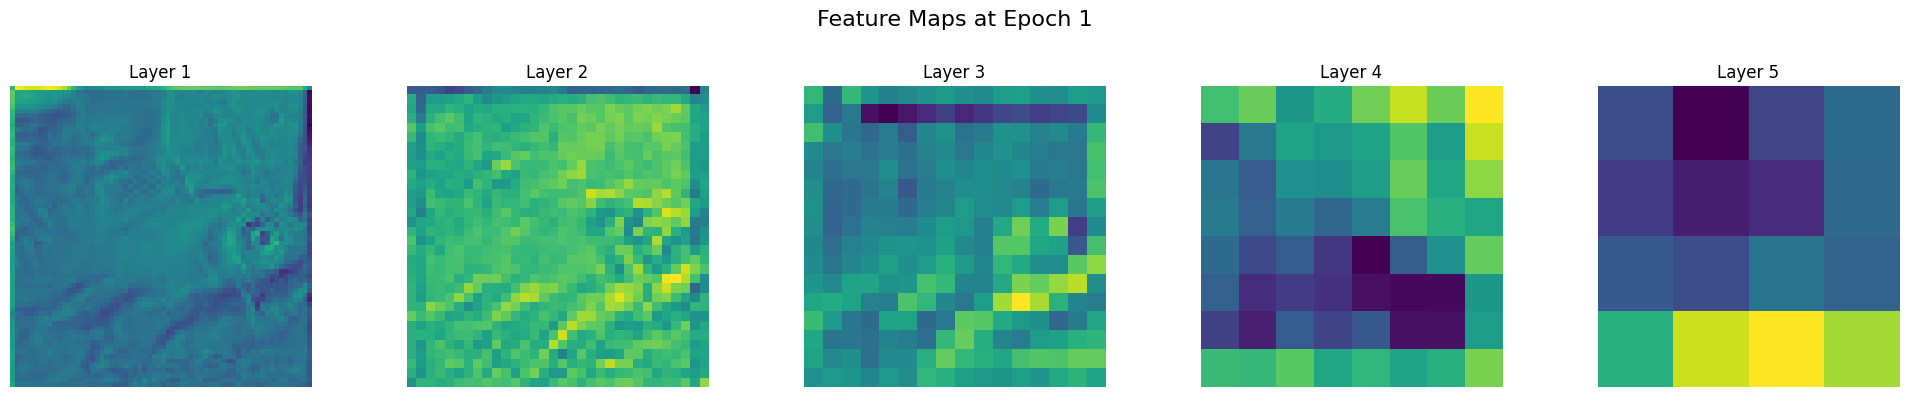

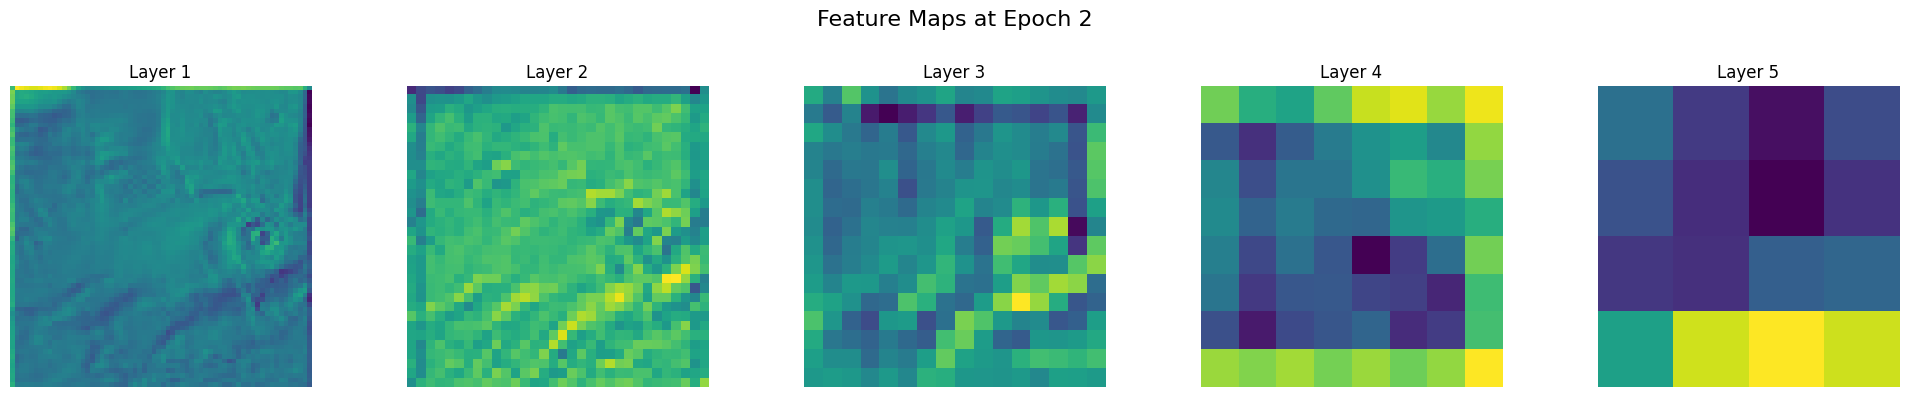

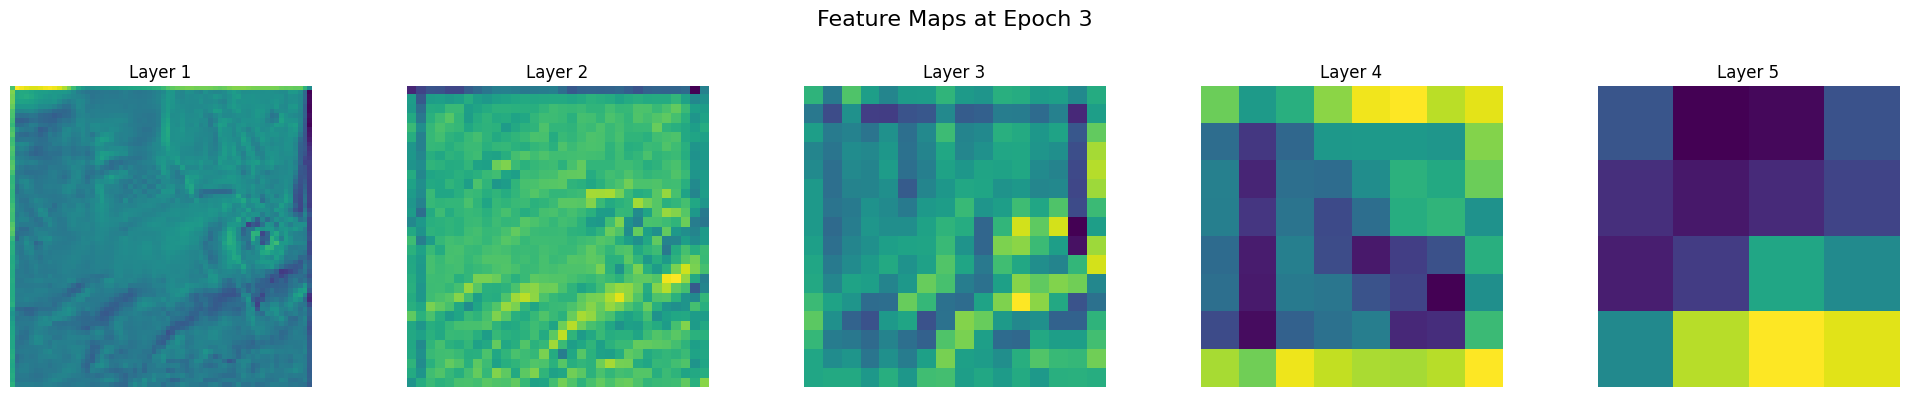

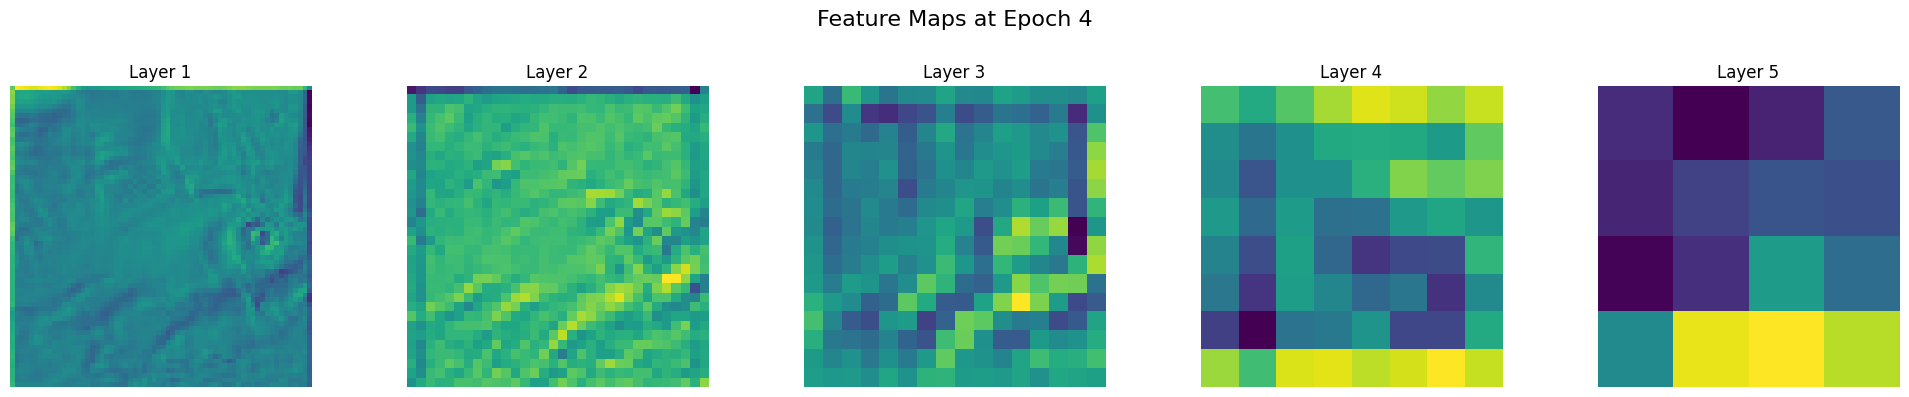

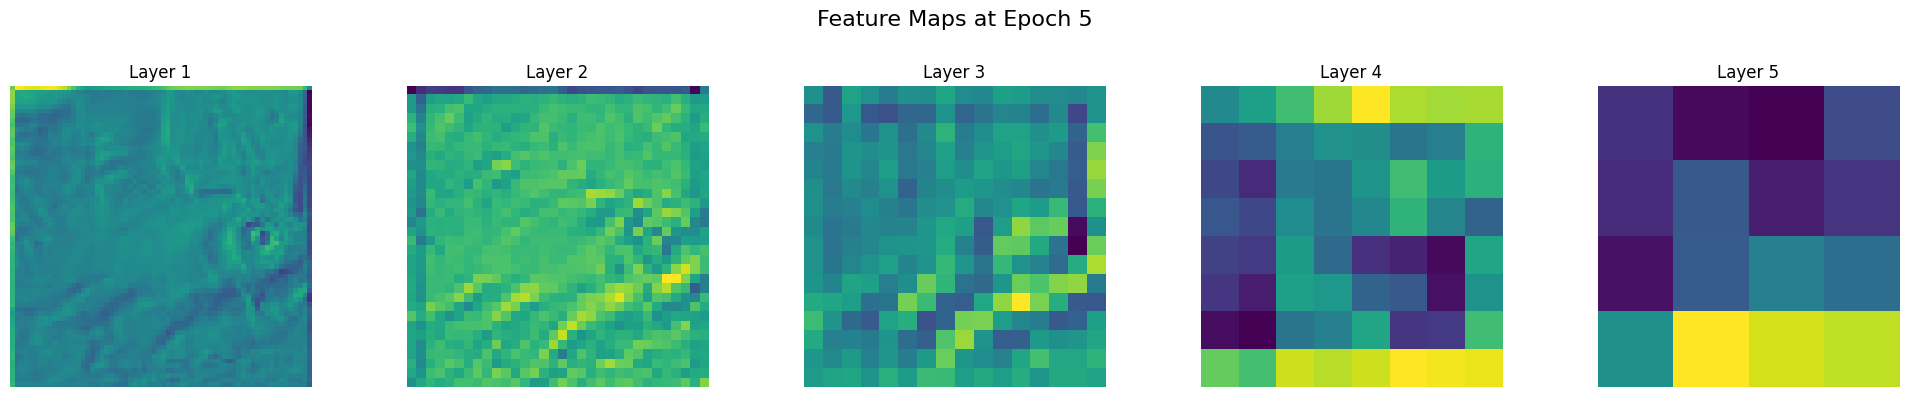

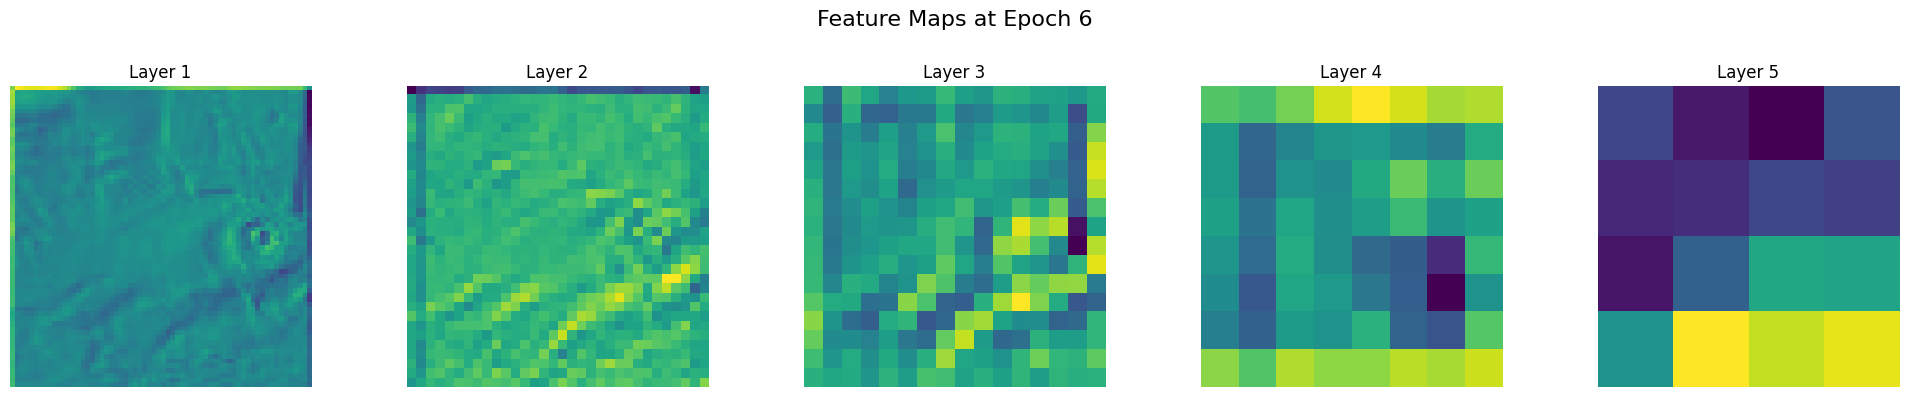

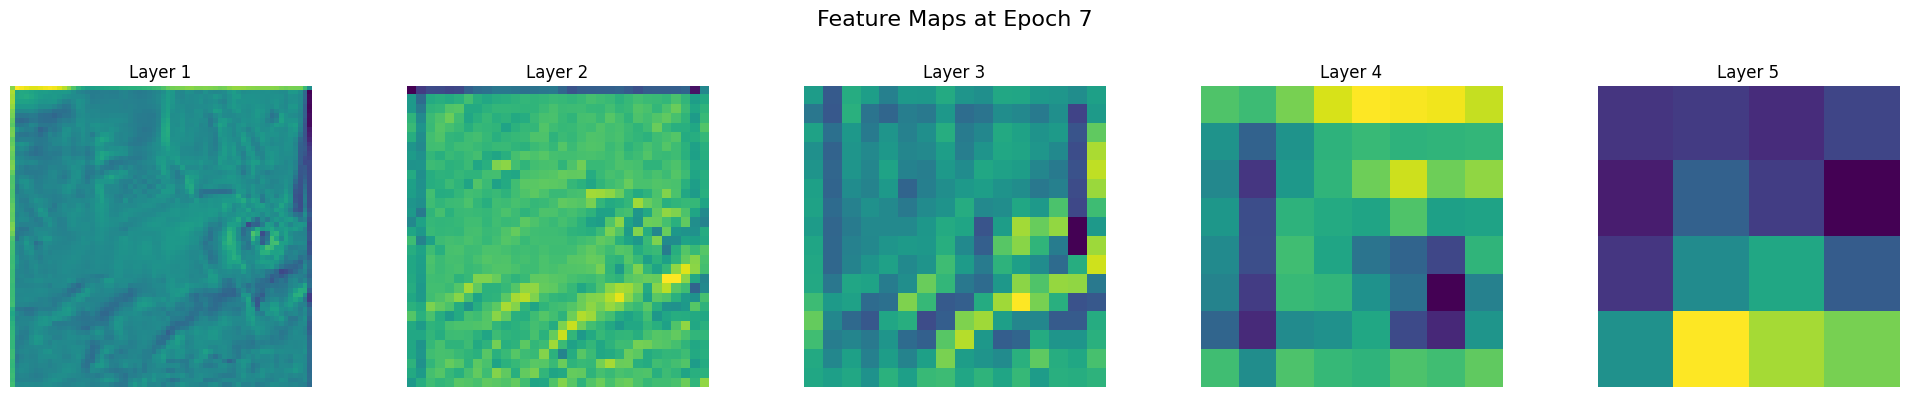

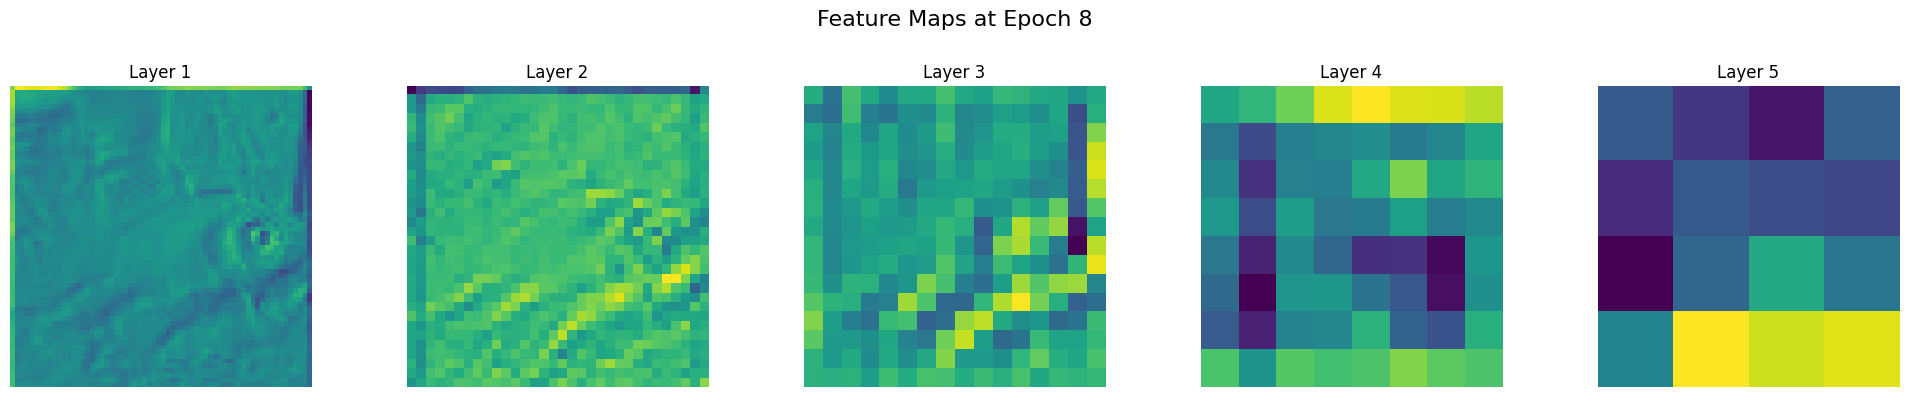

In [14]:
BATCH_SIZE = 64
IMAGE_SIZE = 64
train_loader, val_loader = get_tiny_imagenet_dataloaders(
    batch_size=BATCH_SIZE,
    img_size=IMAGE_SIZE
)

CLASS = 200
LAYER = 5
FILTER = 16  # Ours = 32
BATCHNORM = True
model = CNN(
    num_classes   = CLASS,
    num_layers    = LAYER,
    base_filters  = FILTER,
    use_batchnorm = BATCHNORM
)

x = img
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])
transform_x = transform(x).unsqueeze(0) # for fitting batch shape

LR = 5e-4
EPOCHS = 8
history = train_cnn(transform_x, model, train_loader, val_loader, lr=LR, epochs=EPOCHS)

num_epochs = len(history["val_fm"])
num_layers = len(history["val_fm"][0])

for epoch_idx in range(num_epochs):
    feature_maps = history["val_fm"][epoch_idx]

    fig, axes = plt.subplots(1, num_layers, figsize=(4 * num_layers, 4))
    fig.suptitle(f"Feature Maps at Epoch {epoch_idx + 1}", fontsize=16)

    for layer_idx in range(num_layers):
        ax = axes[layer_idx] if num_layers > 1 else axes
        
        # [batch, channel, H, W]
        fm = feature_maps[layer_idx][0, 0].numpy()

        fm_norm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)

        ax.imshow(fm_norm, cmap="viridis")
        ax.axis("off")
        ax.set_title(f"Layer {layer_idx + 1}")

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

# 2. RNN

## Load sunspots dataset

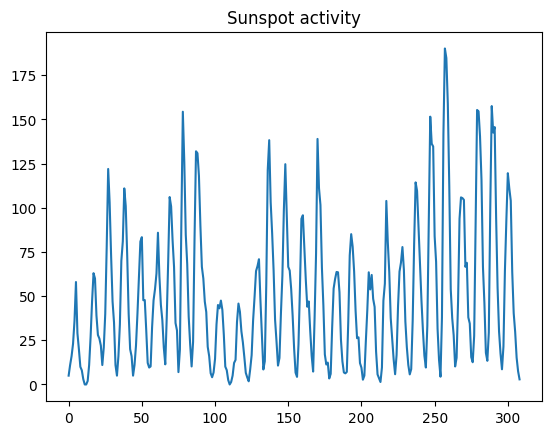

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.datasets import sunspots
from tqdm import tqdm

sunspots_dataset = sunspots.load().data['SUNACTIVITY']
plt.plot(sunspots_dataset)
plt.title("Sunspot activity")
plt.show()

In [16]:
# Define Dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len=12):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+self.seq_len]
        return x, y

SEQ_LEN = 12
TRAIN_RATIO = 0.8
BATCH_SIZE = 32
full_data = np.array(sunspots_dataset, dtype=np.float32)
train_size = int(len(full_data) * TRAIN_RATIO)

train_data = full_data[:train_size]
test_data  = full_data[train_size - SEQ_LEN:]

train_dataset = TimeSeriesDataset(train_data, SEQ_LEN)
test_dataset  = TimeSeriesDataset(test_data, SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## TODO: Elman RNN

In [17]:
class ElmanRNN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128):
        super().__init__()
        self.rnn = nn.RNNCell(input_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, h0=None):
        # x: (batch, seq_len)
        batch_size, seq_len = x.size()

        # initialize hidden state
        if h0 is None:
            h_t = torch.zeros(batch_size, self.rnn.hidden_size, device=x.device)
        else:
            h_t = h0.squeeze(0) # RNNCell expects (B, H)

        # TODO: define forward function (ElmanRNN)
        for t in range(seq_len):
            x_t = x[:, t].unsqueeze(-1)
            h_t = self.rnn(x_t, h_t)

        logits = self.fc(h_t)
        return logits, h_t.unsqueeze(0)


## TODO: Jordan RNN


In [18]:
class JordanRNN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128):
        super().__init__()
        self.rnn = nn.RNNCell(input_dim + 1, hidden_dim) # x + y_prev
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, h0=None):
        # x: (batch, seq_len)
        batch_size, seq_len = x.size()

        # initialize hidden state
        if h0 is None:
            h_t = torch.zeros(batch_size, self.rnn.hidden_size, device=x.device)
        else:
            h_t = h0.squeeze(0) # RNNCell expects (B, H)

        # initialize prev input
        y_prev = torch.zeros(batch_size, 1, device=x.device)

        # TODO: define forward function (JordanRNN)
        for t in range(seq_len):
            x_t = x[:, t].unsqueeze(-1)
            rnn_input = torch.cat([x_t, y_prev], dim=1)   # 입력 + 이전 출력
            h_t = self.rnn(rnn_input, h_t)  # hidden 업데이트
            y = self.fc(h_t)  # 현재 출력 (batch, 1)
            y_prev = y

        logits = y
        return logits, h_t.unsqueeze(0)

## Define LSTM

In [19]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, h0=None):
        x = x.unsqueeze(-1)
        out, h = self.lstm(x, h0)
        logits = self.fc(out[:, -1])
        return logits, h

## RNN train, evaluation functions


In [22]:
def train_rnn(model, train_loader, test_loader=None, epochs=1, lr=1e-4):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {
        "train_loss": [],
        "test_loss": []
    }

    for ep in tqdm(range(epochs)):
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device).unsqueeze(1)

            pred, _ = model(x)
            loss = criterion(pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train = total_loss / len(train_loader)
        history["train_loss"].append(avg_train)

        if test_loader is not None:
            test_loss = eval_rnn(model, test_loader)
            history["test_loss"].append(test_loss)
            model.train()

    return history

def eval_rnn(model, test_loader):
    model.eval()
    criterion = nn.MSELoss()
    losses = []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device).unsqueeze(1)
            pred, _ = model(x)
            loss = criterion(pred, y)
            losses.append(loss.item())

    return np.mean(losses)

## Performance Comparison of ElmanRNN, JordanRNN, and LSTM

1. Try adjusting the epochs and learning rate (LR), and analyze which model shows the best performance.
2. Between the ElmanRNN and JordanRNN models, which one generally performed better? Using the same epochs and learning rate (LR), include a visualization figure and explain why.

In [ ]:
LR_LIST = [1e-1, 1e-2, 1e-3, 1e-4]
EPOCH_LIST = [10, 25, 100, 1000]

all_history = {}
all_results = {}

# Learning Rate Sweep (Epochs 고정)
all_history["lr_sweep"] = {}
all_results["lr_sweep"] = {}

for lr in LR_LIST:
    print(f"\nRunning LR = {lr}")

    models = {
        "ElmanRNN": ElmanRNN().to(device),
        "JordanRNN": JordanRNN().to(device),
        "LSTM": LSTMModel().to(device)
    }

    history = {}
    results = {}

    EPOCH_FIXED = 25

    for name, model in models.items():
        history[name] = train_rnn(
            model,
            train_loader,
            test_loader=test_loader,
            epochs=EPOCH_FIXED,
            lr=lr
        )
        test_loss = eval_rnn(model, test_loader)
        results[name] = test_loss

    all_history["lr_sweep"][lr] = history
    all_results["lr_sweep"][lr] = results

for lr, res in all_results["lr_sweep"].items():
    print(f"\nLR = {lr}")
    for model_name, mse in res.items():
        print(f"- {model_name}: {mse:.6f}")


# Epoch Sweep (LR = 1e-2)
LR_FIXED = 1e-2

all_history["epoch_sweep"] = {}
all_results["epoch_sweep"] = {}

for epochs in EPOCH_LIST:
    print(f"\nRunning EPOCHS = {epochs}")

    models = {
        "ElmanRNN": ElmanRNN().to(device),
        "JordanRNN": JordanRNN().to(device),
        "LSTM": LSTMModel().to(device)
    }

    history = {}
    results = {}

    for name, model in models.items():
        history[name] = train_rnn(
            model,
            train_loader,
            test_loader=test_loader,
            epochs=epochs,
            lr=LR_FIXED
        )
        test_loss = eval_rnn(model, test_loader)
        results[name] = test_loss

    all_history["epoch_sweep"][epochs] = history
    all_results["epoch_sweep"][epochs] = results

for epochs, res in all_results["epoch_sweep"].items():
    print(f"\nEPOCHS = {epochs}")
    for model_name, mse in res.items():
        print(f"- {model_name}: {mse:.2f}")



Running LR = 0.1


  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:00<00:00, 53.60it/s]



Running LR = 0.01


100%|██████████| 25/25 [00:00<00:00, 51.93it/s]


...


Running EPOCHS = 100


100%|██████████| 100/100 [00:01<00:00, 50.86it/s]



Running EPOCHS = 1000


100%|██████████| 1000/1000 [00:19<00:00, 52.26it/s]


EPOCHS = 10
ElmanRNN: 3358.02
JordanRNN: 3578.43
LSTM: 3502.42

EPOCHS = 25
ElmanRNN: 2551.13
JordanRNN: 3495.43
LSTM: 2556.02

EPOCHS = 100
ElmanRNN: 773.69
JordanRNN: 1709.18
LSTM: 502.51

EPOCHS = 1000
ElmanRNN: 556.80
JordanRNN: 1045.64
LSTM: 480.79


In [ ]:
# Models
models = {
    "ElmanRNN": ElmanRNN().to(device),
    "JordanRNN": JordanRNN().to(device),
    "LSTM": LSTMModel().to(device)
}

# Hyperparameters
EPOCHS = 1000  # origin = 25
LR = 1e-2  # origin = 1e-4

# Train
history = {}
results = {}
for name, model in models.items():
    print("model name:", name)
    history[name] = train_rnn(model, train_loader, test_loader=test_loader, epochs=EPOCHS, lr=LR)
    test_loss = eval_rnn(model, test_loader)
    results[name] = test_loss

# Result
print("\nFinal Comparison (MSE)")
for k, v in results.items():
    print(f"- {k}: {v:.6f}")

model name: ElmanRNN


100%|██████████| 1000/1000 [00:47<00:00, 21.00it/s]


model name: JordanRNN


100%|██████████| 1000/1000 [01:06<00:00, 15.14it/s]


model name: LSTM


100%|██████████| 1000/1000 [00:18<00:00, 53.18it/s]



Final Comparison (MSE):
ElmanRNN 806.3333740234375
JordanRNN 996.7909240722656
LSTM 435.2404479980469


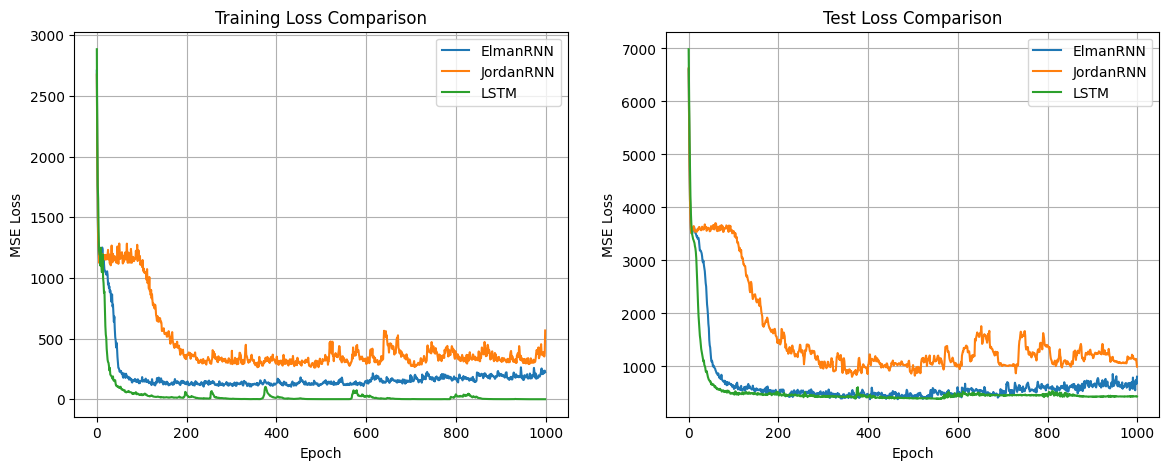

In [ ]:
# Visualize train & test loss
plt.figure(figsize=(14, 5))

# Train Loss
plt.subplot(1, 2, 1)
for name, h in history.items():
    plt.plot(h["train_loss"], label=name)
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

# Test Loss
plt.subplot(1, 2, 2)
for name, h in history.items():
    if len(h["test_loss"]) > 0:
        plt.plot(h["test_loss"], label=name)
plt.title("Test Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()

# 3-4. K-means & GMM

## Create dataset

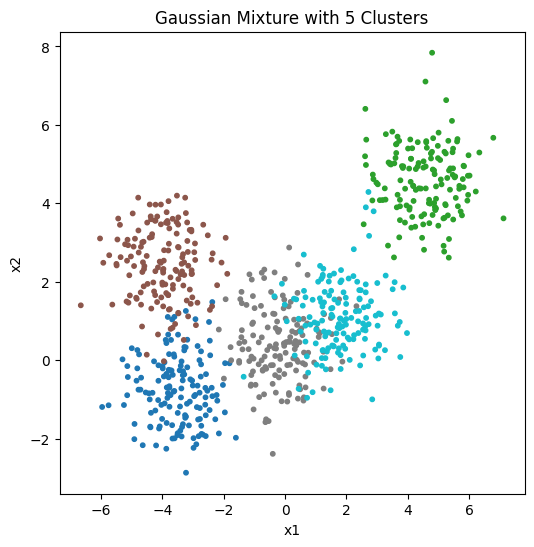

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 2D dataset
def make_gaussian_mixture(n_clusters=3, samples_per_cluster=200, random_state=0):
    """
    Generate a Gaussian mixture dataset with `n_clusters` clusters.

    Args:
        n_clusters: Number of clusters to generate.
        samples_per_cluster: Number of samples in each cluster.
        random_state: Random seed for reproducibility.

    Returns:
        X: (N, 2) array of generated data points.
        y_true: (N,) array of true cluster indices (0 to n_clusters-1).
    """
    np.random.seed(random_state)

    X_list = []
    y_list = []

    for k in range(n_clusters):
        # uniform mean
        mean = np.random.uniform(-5, 5, size=2)

        # common covariance
        cov = np.array(
            [[0.8, 0.0],
             [0.0, 0.8]]
        )

        # sample
        Xk = np.random.multivariate_normal(mean, cov, samples_per_cluster)

        X_list.append(Xk)
        y_list.append(np.ones(samples_per_cluster) * k)

    X = np.vstack(X_list)
    y_true = np.hstack(y_list).astype(int)
    return X, y_true

# Create dataset
N_CLUSTER = 5
SAMPLES_PER_CLUSTER = 150
RANDOM_STATE = 1119
X, y = make_gaussian_mixture(
    n_clusters=N_CLUSTER,
    samples_per_cluster=SAMPLES_PER_CLUSTER,
    random_state=RANDOM_STATE
)

# Visualize dataset
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=10, cmap='tab10')
plt.title(f"Gaussian Mixture with {N_CLUSTER} Clusters")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 3. TODO: KMeans (hard assignment)

In [27]:
class KMeans:
    def __init__(self, n_clusters=3, max_iters=100, tolerance=1e-4, random_state=0):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tolerance = tolerance
        self.random_state = random_state

        self.centers = None
        self.labels_ = None

    def _init_centers(self, X):
        np.random.seed(self.random_state)

        # TODO: initialize center points, from X for n_clusters
        indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centers = X[indices]

    def _assign_clusters(self, X):
        # TODO: assign cluster by distance between data points and centers
        # Hint:
        # X shape: (N, D)
        # centers shape: (K, D)
        distances = np.linalg.norm(X[:, np.newaxis] - self.centers, axis=2)
        return np.argmin(distances, axis=1)

    def _update_centers(self, X, labels):
        # TODO: update new centers (mean of points belonging to each cluster)
        # Hint: If an empty cluster is created, it is possible to use a random point as the center.
        new_centers = np.zeros((self.n_clusters, X.shape[1]))
        for k in range(self.n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                new_centers[k] = cluster_points.mean(axis=0)
            else:
                new_centers[k] = X[np.random.choice(X.shape[0])]
        return new_centers

    def fit(self, X):
        # Init
        self._init_centers(X)

        # Iterations
        for it in range(self.max_iters):
            labels = self._assign_clusters(X) # assign
            new_centers = self._update_centers(X, labels) # update
            shift = np.linalg.norm(self.centers - new_centers) # changes
            self.centers = new_centers
            if shift < self.tolerance:
                break

        # assign clusters to data
        self.labels_ = self._assign_clusters(X)
        return self

    def predict(self, X):
        return self._assign_clusters(X)

## 4. TODO: GMM (soft assignment)

In [28]:
# Define gaussian_pdf function
import numpy as np

def gaussian_pdf(X, mean, cov):
    """
    X: (N, D)
    mean: (D,)
    cov: (D, D)
    return: (N,) density values
    """
    D = X.shape[1]
    cov_det = np.linalg.det(cov) + 1e-12
    cov_inv = np.linalg.inv(cov + 1e-12 * np.eye(D))

    diff = X - mean
    expo = np.einsum("ni,ij,nj->n", diff, cov_inv, diff)
    norm_const = np.sqrt((2 * np.pi) ** D * cov_det)
    return np.exp(-0.5 * expo) / (norm_const + 1e-12)

In [29]:
class GMM:
    def __init__(self, n_components=3, max_iters=100, tolerance=1e-4, random_state=0):
        self.n_components = n_components
        self.max_iters = max_iters
        self.tolerance = tolerance
        self.random_state = random_state

        self.means = None
        self.covs = None
        self.weights = None
        self.resp_ = None
        self.labels_ = None

    def _init_params(self, X, cov=0.8):
        np.random.seed(self.random_state)
        N, D = X.shape

        # TODO: Using random initializing
        # Need to set self.means, self.covs, self.weights
        # Random mean initialization
        indices = np.random.choice(N, self.n_components, replace=False)
        self.means = X[indices]
        self.covs = np.array([np.eye(D) * cov for _ in range(self.n_components)])
        self.weights = np.ones(self.n_components) / self.n_components

    def _expectation_step(self, X, epsilon=1e-12):
        N = X.shape[0]
        K = self.n_components

        """
        TODO: Expectation-step:
        Compute responsibilities r_nk = pi_k * N(x_n | mean_k, cov_k)
        Normalize for each n.
        """
        r = np.zeros((N, K))
        for k in range(K):
            r[:, k] = self.weights[k] * gaussian_pdf(X, self.means[k], self.covs[k])
        
        r_sum = r.sum(axis=1, keepdims=True) + epsilon
        r = r / r_sum
        
        log_lk = np.sum(np.log(r_sum))
        return r, log_lk

    def _maximization_step(self, X, r, epsilon=1e-12):
        N, D = X.shape
        K = self.n_components

        """
        TODO: Maximization-step:
        - Nk = sum_n r_nk
        - new weight: pi_k = Nk / N
        - new mean: mu_k = (1/Nk) * sum_n r_nk x_n
        - new cov:  (1/Nk) * sum_n r_nk (x_n - mu_k)(x_n - mu_k)^T
        """
        Nk = r.sum(axis=0) + epsilon
        self.weights = Nk / N
        self.means = (r.T @ X) / Nk[:, np.newaxis]
        self.covs = np.zeros((K, D, D))
        for k in range(K):
            diff = X - self.means[k]
            self.covs[k] = (r[:, k, np.newaxis] * diff).T @ diff / Nk[k]
            self.covs[k] += epsilon * np.eye(D)

    def fit(self, X):
        self._init_params(X)
        prev_ll = None

        for it in range(self.max_iters):
            r, log_lk = self._expectation_step(X)
            self._maximization_step(X, r)

            # print(f"[GMM] iter {it}  log-likelihood = {log_lk:.6f}")
            if prev_ll is not None and abs(log_lk - prev_ll) < self.tolerance:
                print(f"GMM converged at iter {it}.")
                break

            prev_ll = log_lk

        self.resp_ = r
        self.labels_ = np.argmax(r, axis=1)

    def predict_proba(self, X):
        r, _ = self._expectation_step(X)
        return r

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

## Visulization

In [30]:
N = 5
MAX_ITERATION = 50
TOLERANCE = 1e-4

kmeans = KMeans(
    n_clusters=N,
    max_iters=MAX_ITERATION,
    tolerance=TOLERANCE,
    random_state=RANDOM_STATE
)
kmeans.fit(X)

gmm = GMM(
    n_components=N,
    max_iters=MAX_ITERATION,
    tolerance=TOLERANCE
)
gmm.fit(X)

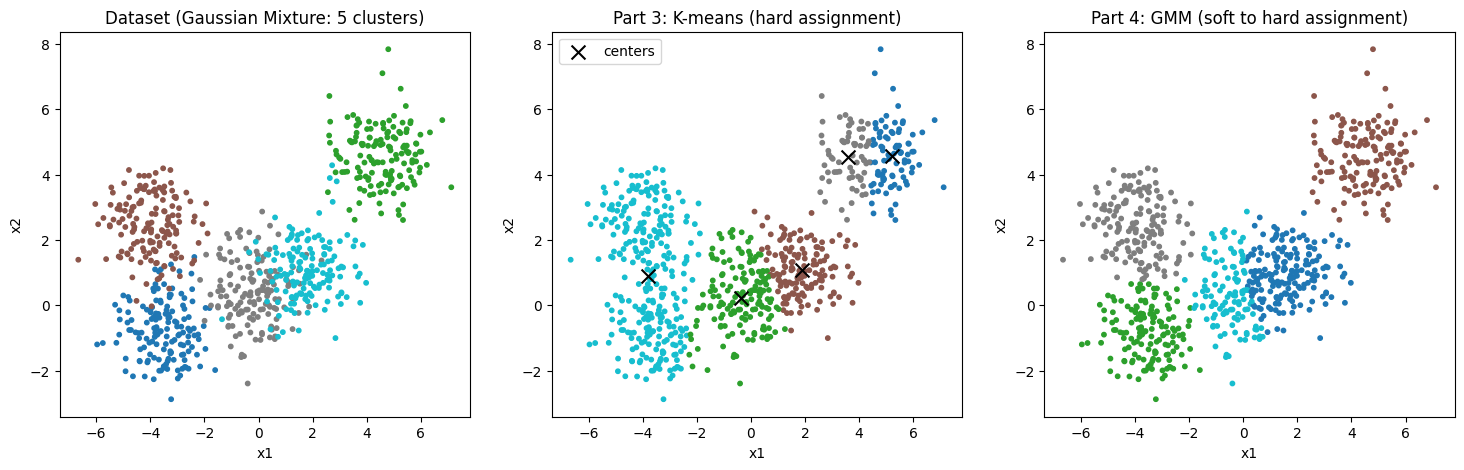

In [31]:
import matplotlib.pyplot as plt

def plot_clusters_subplot(ax, X, labels, centers=None, title=""):
    ax.scatter(X[:,0], X[:,1], c=labels, s=10, cmap='tab10')
    if centers is not None:
        ax.scatter(centers[:,0], centers[:,1],
                   c='black', s=100, marker='x', label='centers')
        ax.legend()
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ground Truth
axes[0].scatter(X[:, 0], X[:, 1], c=y, s=10, cmap='tab10')
axes[0].set_title(f"Dataset (Gaussian Mixture: {N} clusters)")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

# K-means
plot_clusters_subplot(
    axes[1], X, kmeans.labels_, centers=kmeans.centers,
    title="Part 3: K-means (hard assignment)"
)

# GMM
plot_clusters_subplot(
    axes[2], X, gmm.labels_, centers=None,
    title="Part 4: GMM (soft to hard assignment)"
)

plt.show()

Testing with different random states...
Random State 0:
K-means Accuracy: 92.80%
GMM Accuracy:     90.93%
Random State 5:
K-means Accuracy: 92.80%
GMM Accuracy:     78.27%
Random State 10:
K-means Accuracy: 93.20%
GMM Accuracy:     77.47%
Random State 20:
K-means Accuracy: 92.80%
GMM Accuracy:     74.13%
Random State 42:
K-means Accuracy: 93.20%
GMM Accuracy:     70.40%
Random State 100:
K-means Accuracy: 92.80%
GMM Accuracy:     71.20%
Random State 500:
K-means Accuracy: 93.07%
GMM Accuracy:     78.00%
Random State 1000:
K-means Accuracy: 92.80%
GMM Accuracy:     71.07%
Random State 1119:
K-means Accuracy: 66.13%
GMM Accuracy:     51.33%


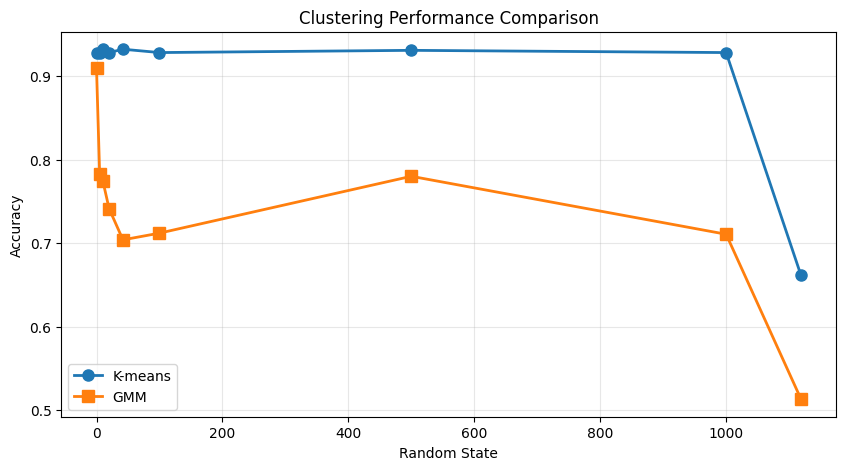


Summary:
K-means - Mean: 89.96%, Std: 8.42%
GMM - Mean: 73.64%, Std: 9.86%


In [ ]:
# Compare the clustering results of K-means and GMM, and analyze which model performs better.
# Discuss the reasons behind the performance differences (Try changing the random state).

# Compare with different random states
random_states = [0, 5, 10, 20, 42, 100, 500, 1000, RANDOM_STATE]
kmeans_results = []
gmm_results = []

for rs in random_states:
    # K-means
    km = KMeans(n_clusters=N_CLUSTER, max_iters=MAX_ITERATION, 
                tolerance=TOLERANCE, random_state=rs)
    km.fit(X)
    
    # GMM
    gm = GMM(n_components=N_CLUSTER, max_iters=MAX_ITERATION, 
             tolerance=TOLERANCE, random_state=rs)
    gm.fit(X)
    
    # Simple accuracy: count how many points match the true labels (with best permutation)
    def cluster_accuracy(y_true, y_pred, n_clusters):
        from itertools import permutations
        best_acc = 0
        for perm in permutations(range(n_clusters)):
            mapping = {i: perm[i] for i in range(n_clusters)}
            y_mapped = np.array([mapping[label] for label in y_pred])
            acc = np.mean(y_mapped == y_true)
            best_acc = max(best_acc, acc)
        return best_acc
    
    km_acc = cluster_accuracy(y, km.labels_, N_CLUSTER)
    gm_acc = cluster_accuracy(y, gm.labels_, N_CLUSTER)
    
    kmeans_results.append(km_acc)
    gmm_results.append(gm_acc)
    
    print(f"Random State {rs}:")
    print(f"K-means Accuracy: {km_acc*100:.2f}%")
    print(f"GMM Accuracy: {gm_acc*100:.2f}%")

# Visualize performance comparison
plt.figure(figsize=(10, 5))
plt.plot(random_states, kmeans_results, 'o-', label='K-means', linewidth=2, markersize=8)
plt.plot(random_states, gmm_results, 's-', label='GMM', linewidth=2, markersize=8)
plt.xlabel('Random State')
plt.ylabel('Accuracy')
plt.title('Clustering Performance Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"K-means - Mean: {np.mean(kmeans_results)*100:.2f}%, Std: {np.std(kmeans_results)*100:.2f}%")
print(f"GMM - Mean: {np.mean(gmm_results)*100:.2f}%, Std: {np.std(gmm_results)*100:.2f}%")

GMM converged at iter 1.

CNN Feature Clustering Results
K-means Purity: 17.91%
GMM Purity: 2.49%


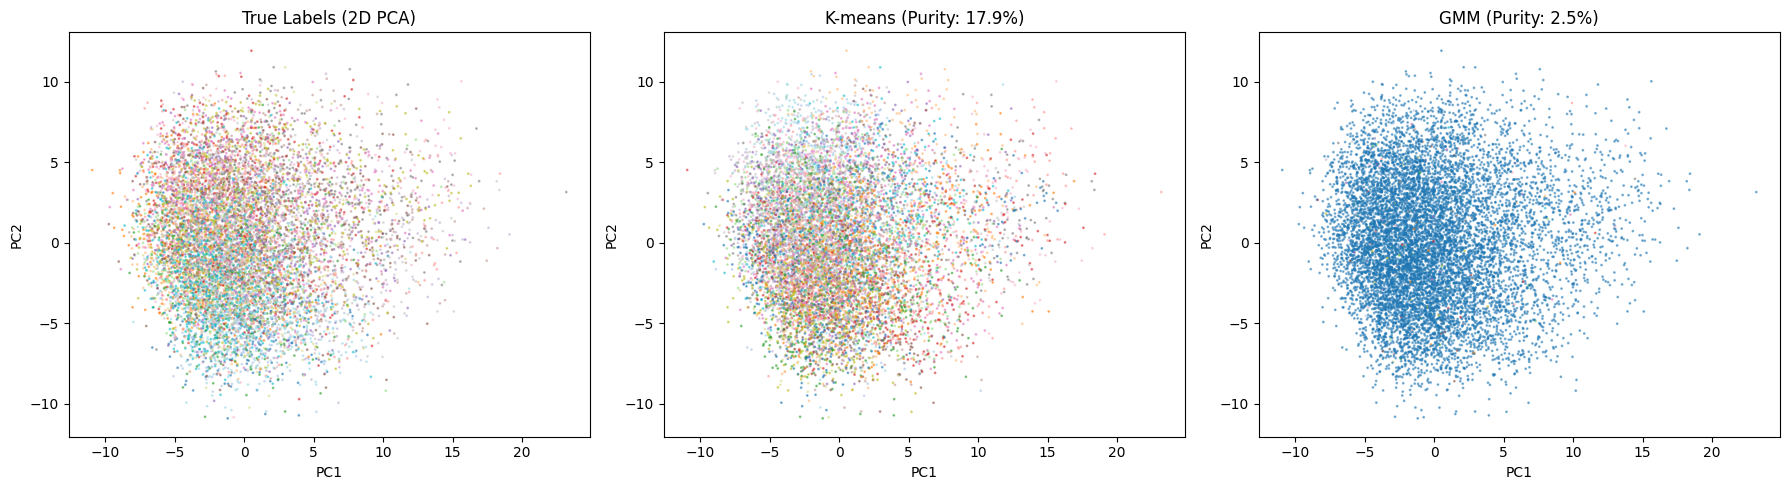

In [38]:
# (Extra credit, Not necessary) If possible, extract features from a CNN, 
# apply PCA for dimensionality reduction, and replace the classifier with a clustering model. 
# Compare the performance and analyze the results (with k-means, GMM). 
# How can you interpret these findings?

from sklearn.decomposition import PCA

cnn_model.eval()
features_list = []
labels_list = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        feats = cnn_model.feature_extractor(images)
        feats_flat = feats.view(feats.size(0), -1)

        features_list.append(feats_flat.cpu().numpy())
        labels_list.append(labels.numpy())

X_features = np.vstack(features_list)
y_true = np.hstack(labels_list)

# PCA (scikit-learn)
N_COMPONENTS = 50
pca_50 = PCA(n_components=N_COMPONENTS, random_state=0)
X_pca = pca_50.fit_transform(X_features)

# Clustering
N_CLUSTERS = 200

kmeans_cnn = KMeans(n_clusters=N_CLUSTERS,
                    max_iters=100, tolerance=1e-4, random_state=42)
kmeans_cnn.fit(X_pca)

gmm_cnn = GMM(n_components=N_CLUSTERS,
              max_iters=50, tolerance=1e-4, random_state=42)
gmm_cnn.fit(X_pca)

# Purity
def clustering_accuracy(y_true, y_pred):
    from collections import Counter
    correct = 0
    for c in np.unique(y_pred):
        mask = (y_pred == c)
        labels = y_true[mask]
        if len(labels) > 0:
            correct += Counter(labels).most_common(1)[0][1]
    return correct / len(y_true)

km_purity  = clustering_accuracy(y_true, kmeans_cnn.labels_)
gmm_purity = clustering_accuracy(y_true, gmm_cnn.labels_)

print("\nCNN Feature Clustering Results")
print(f"K-means Purity: {km_purity * 100:.2f}%")
print(f"GMM Purity: {gmm_purity * 100:.2f}%")

pca_2d = PCA(n_components=2, random_state=0)
X_pca_2d = pca_2d.fit_transform(X_features)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_true,
                s=1, cmap="tab20", alpha=0.5)
axes[0].set_title("True Labels (2D PCA)")

axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_cnn.labels_,
                s=1, cmap="tab20", alpha=0.5)
axes[1].set_title(f"K-means (Purity: {km_purity*100:.1f}%)")

axes[2].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=gmm_cnn.labels_,
                s=1, cmap="tab20", alpha=0.5)
axes[2].set_title(f"GMM (Purity: {gmm_purity*100:.1f}%)")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()
